# Experiment Report

Read-only view of saved experiment artifacts. Re-run `python src/regenerate_plots.py --window-seed N` to refresh plots without re-running heavy compute.

In [1]:
from __future__ import annotations

import ast, json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display


# ── path helpers ──────────────────────────────────────────────────────────
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").exists() and (candidate / "README.md").exists():
            return candidate
    return start

def default_experiment_dir(root: Path) -> Path:
    canonical = root / "results/experiments/data_tim_milan_10min_trainable_200_ctx144_h48/q50_q99_seed42"
    if canonical.exists():
        return canonical
    candidates = sorted((root / "results/experiments").glob("*/*"), key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0] if candidates else canonical

ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

_OVERRIDE = globals().get("EXPERIMENT_DIR_OVERRIDE", None)
EXPERIMENT_DIR = Path(_OVERRIDE) if _OVERRIDE else default_experiment_dir(ROOT)
if not EXPERIMENT_DIR.is_absolute():
    EXPERIMENT_DIR = (ROOT / EXPERIMENT_DIR).resolve()
REPORTS_DIR = EXPERIMENT_DIR / "reports"
CALIBRATED_PATH = EXPERIMENT_DIR / "calibrated_system_eval" / "calibrated_system_eval_comparison.csv"

print(f"Experiment : {EXPERIMENT_DIR}")
print(f"Reports    : {REPORTS_DIR}")


# ── display utils ─────────────────────────────────────────────────────────
def md(text):  display(Markdown(text))
def note(text): md(f"> {text}")

def read_json(path, quiet=False):
    if not path.exists():
        if not quiet: note(f"Missing: `{path.relative_to(ROOT)}`")
        return None
    return json.loads(path.read_text())

def read_csv(path, quiet=False):
    if not path.exists():
        if not quiet: note(f"Missing: `{path.relative_to(ROOT)}`")
        return None
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        if not quiet: note(f"Empty: `{path.relative_to(ROOT)}`")
        return None

def show_png(path, title=None):
    if title: md(f"### {title}")
    if Path(path).exists():
        display(Image(filename=str(path)))
    else:
        note(f"PNG not found: `{Path(path).relative_to(ROOT)}`")

def show_table(path, title=None, rows=20):
    if title: md(f"### {title}")
    df = read_csv(path)
    if df is not None:
        display(df.head(rows))

def parse_seq(value):
    if isinstance(value, (list, np.ndarray)):
        return [float(v) for v in value]
    if pd.isna(value): return []
    if isinstance(value, str):
        for fn in (json.loads, ast.literal_eval):
            try:
                p = fn(value.strip())
                if isinstance(p, (list, tuple)): return [float(v) for v in p]
            except Exception: pass
    return []

def discover_metrics(summary_path, glob_suffix):
    rows = []
    payload = read_json(summary_path, quiet=True)
    if isinstance(payload, dict):
        for split, split_data in payload.get("splits", {}).items():
            for model, mdata in split_data.items():
                m = read_json(ROOT / mdata["metrics_path"], quiet=True)
                if isinstance(m, dict):
                    rows.append({"split": split, "model": model, **m})
    if not rows:
        for p in sorted(summary_path.parent.glob(f"*/{glob_suffix}")):
            m = read_json(p, quiet=True)
            if isinstance(m, dict): rows.append(m)
    return pd.DataFrame(rows)

def normalize_dict(payload):
    if payload is None: return None
    if isinstance(payload, dict):
        try: return pd.json_normalize(payload)
        except Exception: return pd.DataFrame([{"key": k, "value": v} for k, v in payload.items()])
    if isinstance(payload, list): return pd.DataFrame(payload)
    return pd.DataFrame([{"value": payload}])


Experiment : /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/experiments/data_tim_milan_10min_trainable_200_ctx144_h48/q50_q99_seed42
Reports    : /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/experiments/data_tim_milan_10min_trainable_200_ctx144_h48/q50_q99_seed42/reports


## 1. Overview

In [2]:
manifest = read_json(EXPERIMENT_DIR / "manifest.json", quiet=True)
if manifest:
    display(normalize_dict(manifest))

status = read_json(REPORTS_DIR / "stage_status.json", quiet=True)
if isinstance(status, dict) and status.get("stages"):
    md("### Stage Status")
    display(pd.DataFrame(status["stages"]).T)


,dataset_path,timestamp_col,cadence,random_seed,context_length,horizon,quantiles,train_ratio,val_ratio,test_ratio,num_rows,num_series,series_columns,created_at_utc,train_split.start_idx,train_split.end_idx,val_split.start_idx,val_split.end_idx,test_split.start_idx,test_split.end_idx
0,data/data_tim_milan_10min_trainable_200.csv,timestamp,10min,42,144,48,"[0.5, 0.99]",0.7,0.1,0.2,8928,200,"[MI1, MI2, MI3, MI4, MI5, MI6, MI7, MI8, MI9, ...",2026-04-16T19:24:20.154830+00:00,0,6249,6249,7142,7142,8928


### Stage Status

,status,started_at_utc,finished_at_utc,duration_sec,command,metrics,plots,report_index,published_plots
prepare_data,success,2026-04-16T19:24:19.795404+00:00,2026-04-16T19:24:20.257326+00:00,0.462,[/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Rep...,{'dataset_path': 'data/data_tim_milan_10min_tr...,{'split_summary_plot': 'results/experiments/da...,results/experiments/data_tim_milan_10min_train...,{'split_summary_plot': '/Users/colinminini/Des...
train,success,2026-04-16T19:24:20.257456+00:00,2026-04-16T20:35:46.583326+00:00,4286.314,[/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Rep...,{'deepar': {'monitor_val_loss': 2.188639804982...,{'training_loss_plot': 'results/experiments/da...,results/experiments/data_tim_milan_10min_train...,{'split_summary_plot': '/Users/colinminini/Des...
forecast_eval,success,2026-04-17T09:53:22.984896+00:00,2026-04-17T09:54:22.444545+00:00,59.46,[/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Rep...,"{'val': {'chronos2': {'model': 'chronos2', 'sp...",{'forecast_eval_test_plot': 'results/experimen...,results/experiments/data_tim_milan_10min_train...,{'energy_pareto_test_plot': '/Users/colinminin...
system_eval,success,2026-04-17T09:54:22.444985+00:00,2026-04-17T09:54:47.820633+00:00,25.376,[/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Rep...,"{'test': {'chronos2': {'model': 'chronos2', 's...",{'system_eval_test_plot': 'results/experiments...,results/experiments/data_tim_milan_10min_train...,{'energy_pareto_test_plot': '/Users/colinminin...
energy_eval,success,2026-04-17T09:54:47.821074+00:00,2026-04-17T09:54:51.763417+00:00,3.942,[/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Rep...,"{'test': {'chronos2': {'model': 'chronos2', 't...",{},results/experiments/data_tim_milan_10min_train...,{'energy_pareto_test_plot': '/Users/colinminin...


## 2. Data Split

,split,start_idx,end_idx,num_rows
0,train,0,6249,6249
1,val,6249,7142,893
2,test,7142,8928,1786


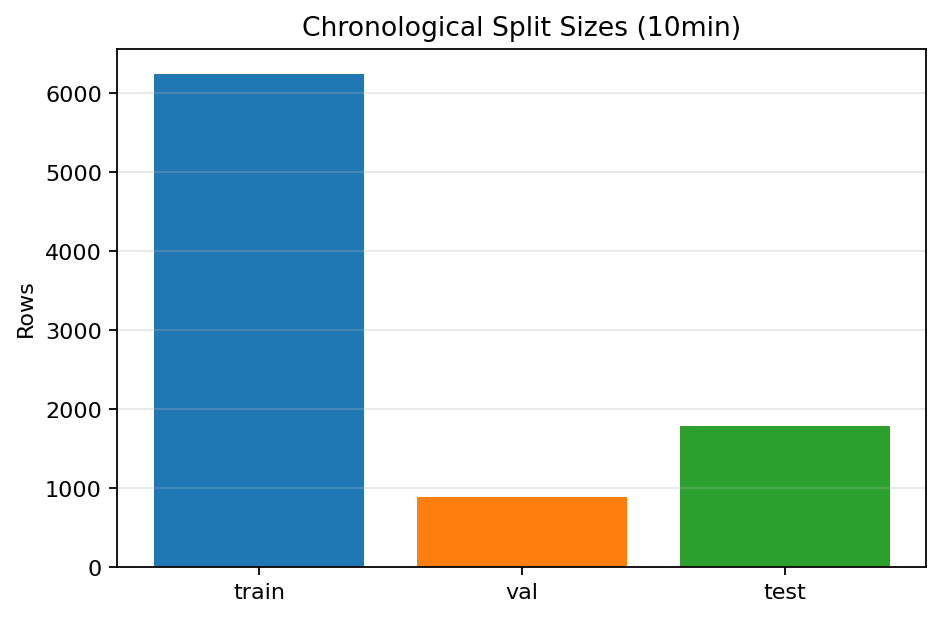

In [3]:
show_table(EXPERIMENT_DIR / "split_summary.csv")
show_png(REPORTS_DIR / "prepare_data_split_summary.png")


## 3. Training

,manifest_path,device,models.deepar.history_path,models.deepar.checkpoint_path,models.deepar.max_iterations,models.deepar.patience_iterations,models.deepar.validate_epochs,models.deepar.validate_every,models.deepar.train_window_step,models.deepar.training_schedule.steps_per_epoch,...,models.tft.monitor_metrics.monitor_val_loss,models.tft.monitor_metrics.monitor_val_rmse,models.tft.monitor_metrics.val.rmse_q50,models.tft.monitor_metrics.val.pinball_q50,models.tft.monitor_metrics.val.pinball_q95,models.tft.monitor_metrics.val.coverage_q95,models.tft.monitor_metrics.val.interval_width_mean,models.tft.monitor_metrics.best_val,models.tft.monitor_metrics.last_iteration,models.tft.monitor_metrics.monitor
0,results/experiments/data_tim_milan_10min_train...,mps,results/experiments/data_tim_milan_10min_train...,results/experiments/data_tim_milan_10min_train...,94710,9471,1,3157,6,3157,...,0.607636,5.921406,5.921406,1.109585,0.106631,0.972853,6.506008,1.15213,12628,pinball


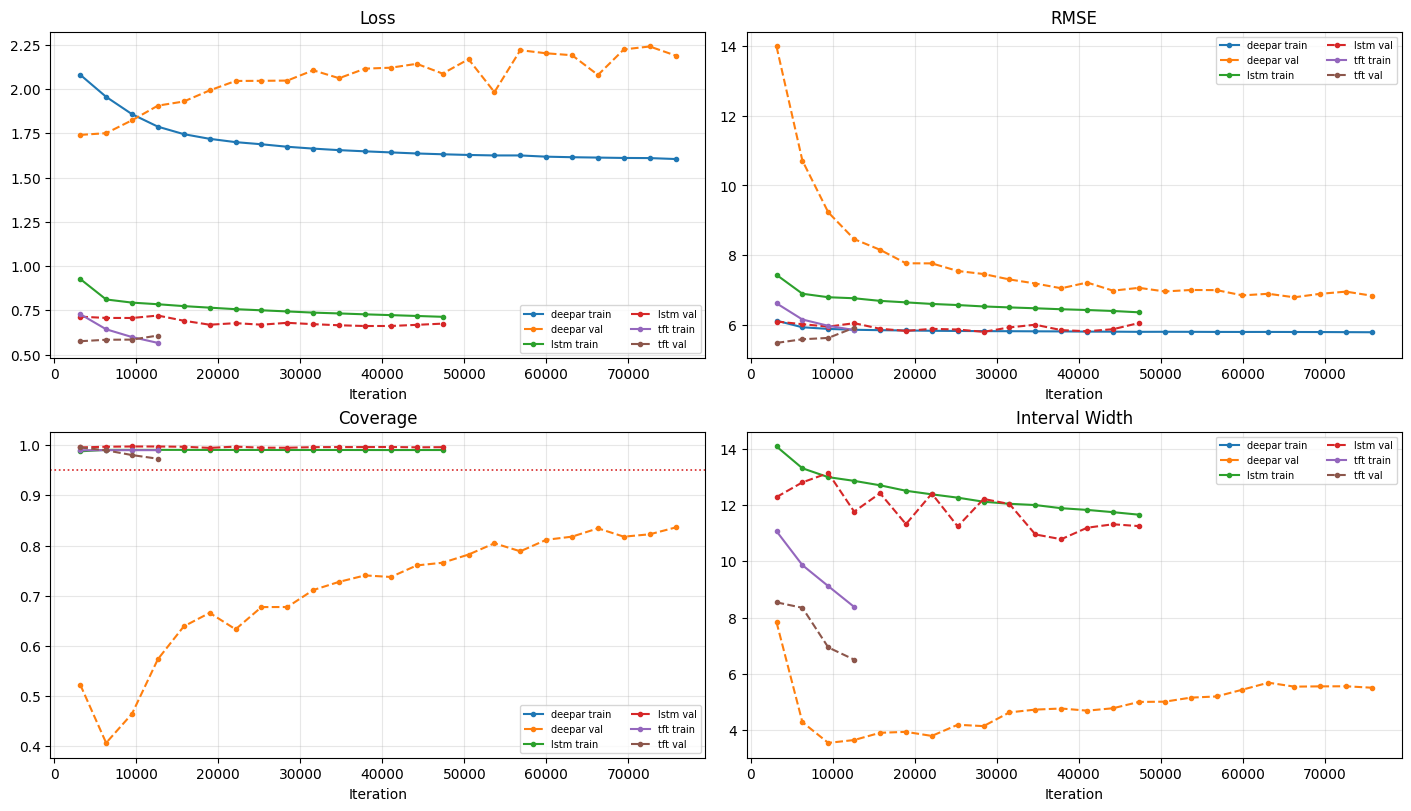

In [4]:
training_summary = read_json(EXPERIMENT_DIR / "training" / "training_summary.json", quiet=True)
if training_summary:
    display(normalize_dict(training_summary))

# ── training curves ───────────────────────────────────────────────────────
history_paths = sorted((EXPERIMENT_DIR / "training").glob("*_history.json"))
histories = {}
for p in history_paths:
    h = read_json(p, quiet=True)
    if isinstance(h, dict):
        histories[p.stem.replace("_history", "")] = h

if histories:
    metric_specs = [("loss", "Loss"), ("rmse", "RMSE"), ("coverage", "Coverage"), ("interval_width", "Interval Width")]
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
    for ax, (key, title) in zip(axes.flat, metric_specs):
        for model, history in histories.items():
            x = history.get("iteration") or list(range(1, 100))
            for split, ls in [("train", "-"), ("val", "--")]:
                vals = history.get(f"{split}_{key}", [])
                if vals:
                    ax.plot(x[:len(vals)], vals, linestyle=ls, marker="o", markersize=3, linewidth=1.5, label=f"{model} {split}")
        ax.set_title(title); ax.set_xlabel("Iteration"); ax.grid(alpha=0.3)
        ax.legend(fontsize=7, ncol=2)
        if key == "coverage":
            ax.axhline(0.95, color="#d62728", linestyle=":", linewidth=1.2, label="target")
    display(fig); plt.close(fig)
else:
    for metric in ["training_loss", "training_rmse", "training_coverage", "training_interval_width"]:
        show_png(REPORTS_DIR / f"{metric}.png")


## 4. Forecast Evaluation

,split,model,num_windows_total,rmse_q50,pinball_q50,pinball_q95,coverage_q95,interval_width_mean
0,test,chronos2,7400,7.070477,2.108417,0.189705,0.953018,12.095557
1,test,deepar,7400,5.942035,1.489202,0.328546,0.840315,5.066291
2,test,lstm,7400,6.102687,1.513836,0.128766,0.996588,10.168150
3,test,seasonal_naive,7400,7.262978,1.404979,0.179769,0.926526,6.494678
4,test,tft,7400,5.756299,1.184883,0.111978,0.981867,7.050634
5,val,chronos2,3600,7.229148,1.687570,0.173999,0.993646,15.170162
6,val,deepar,3600,6.731247,1.623893,0.358923,0.841238,5.543729
7,val,lstm,3600,6.488046,1.665643,0.146789,0.996123,10.876160
8,val,seasonal_naive,3600,7.587165,1.472632,0.186148,0.931944,7.239300
9,val,tft,3600,5.465645,1.086155,0.091317,0.993698,7.843791


### Forecast Metrics — Test

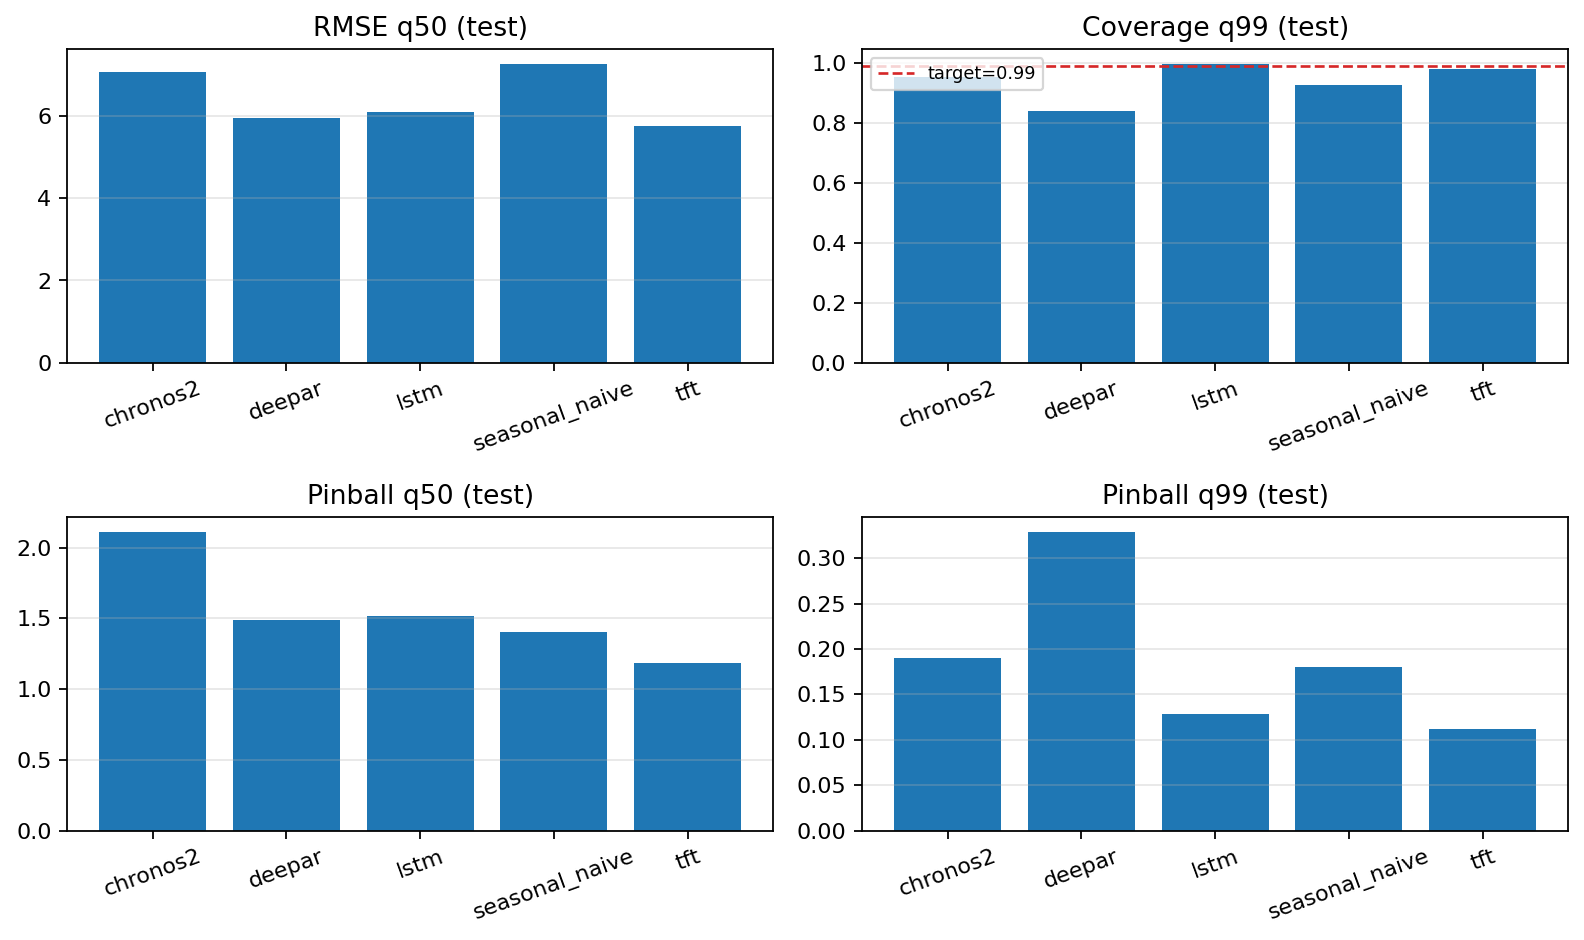

### Forecast Metrics — Val

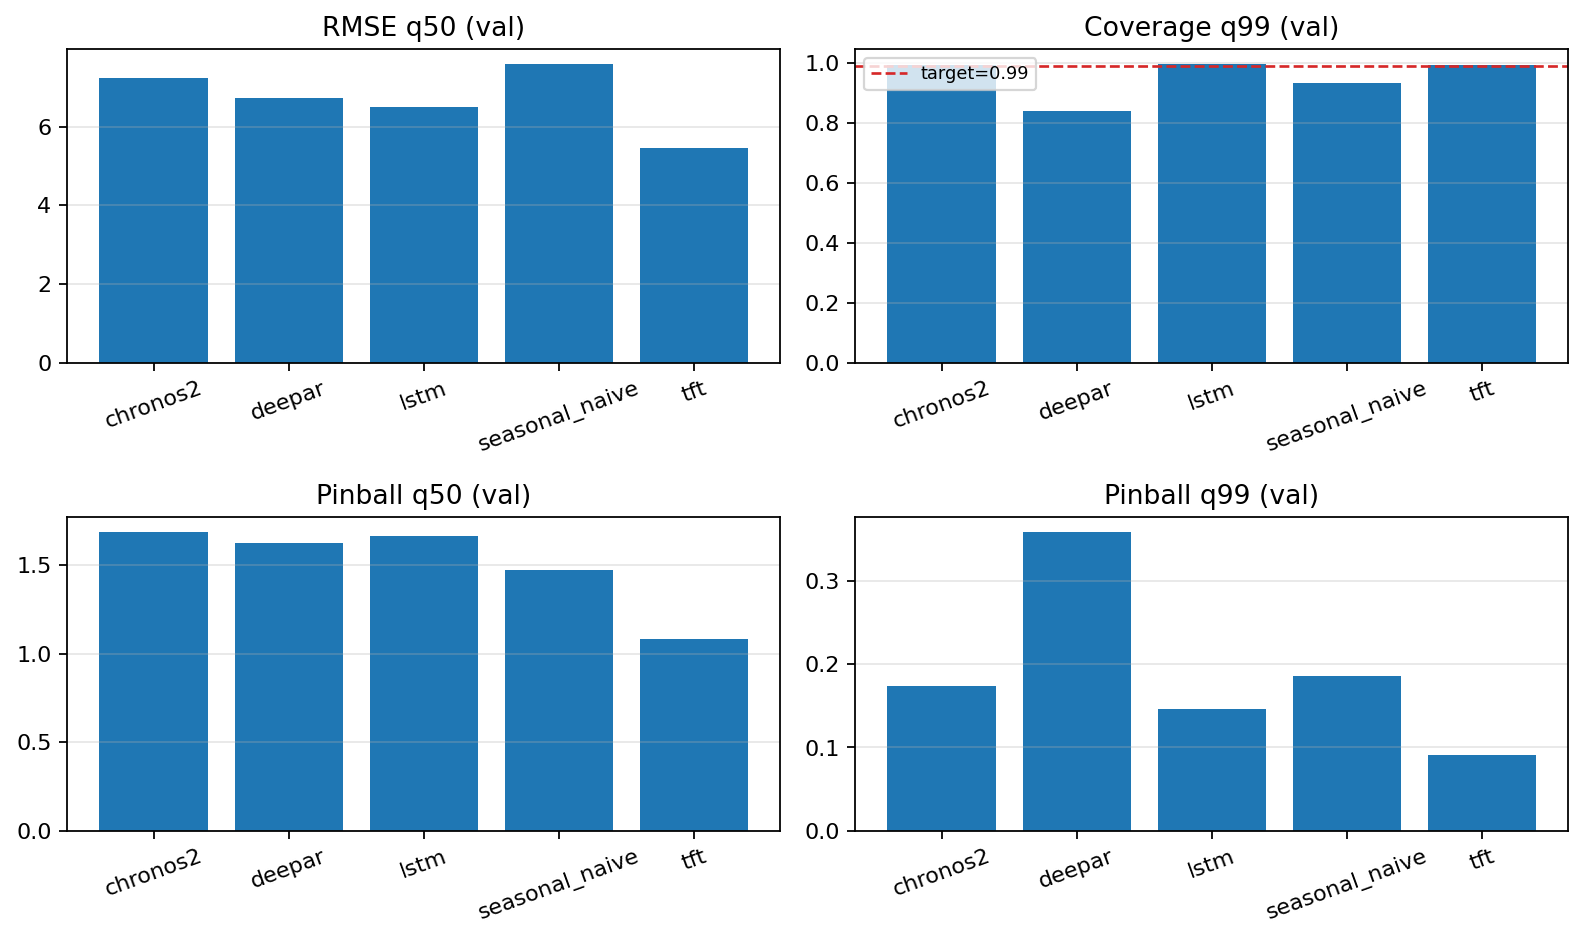

### Forecast Example Windows (Test)

### lstm

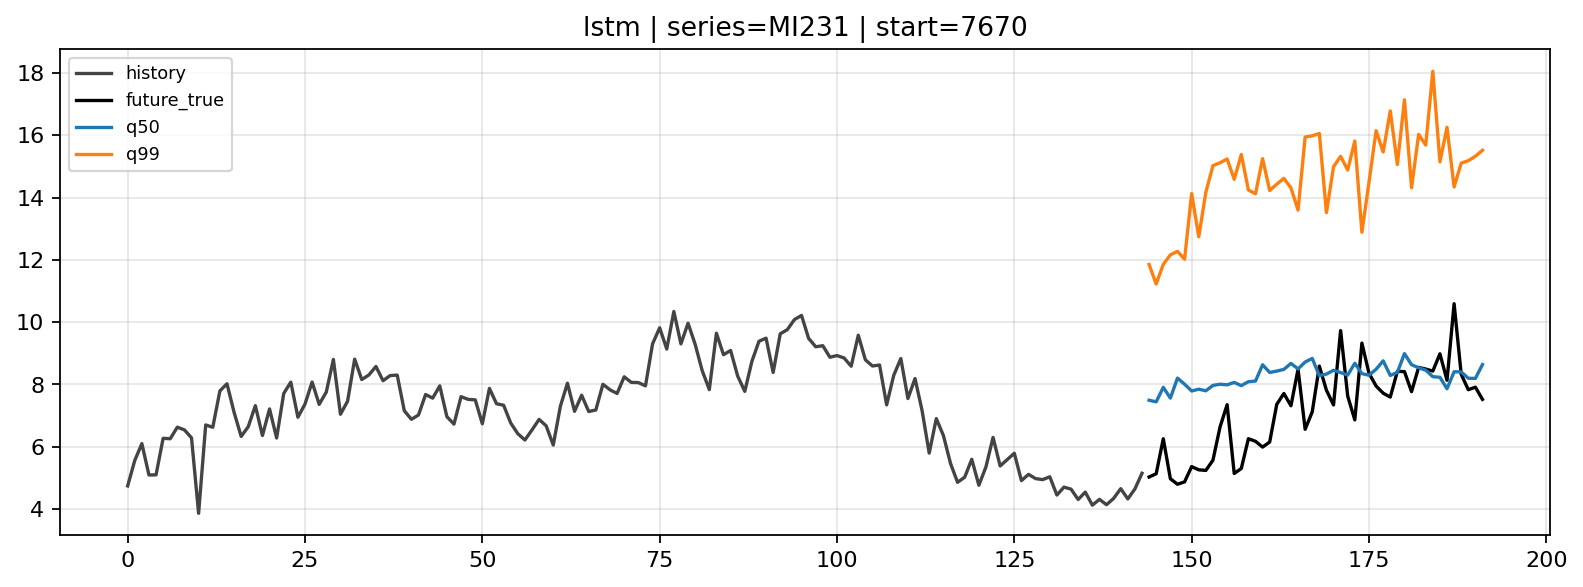

### deepar

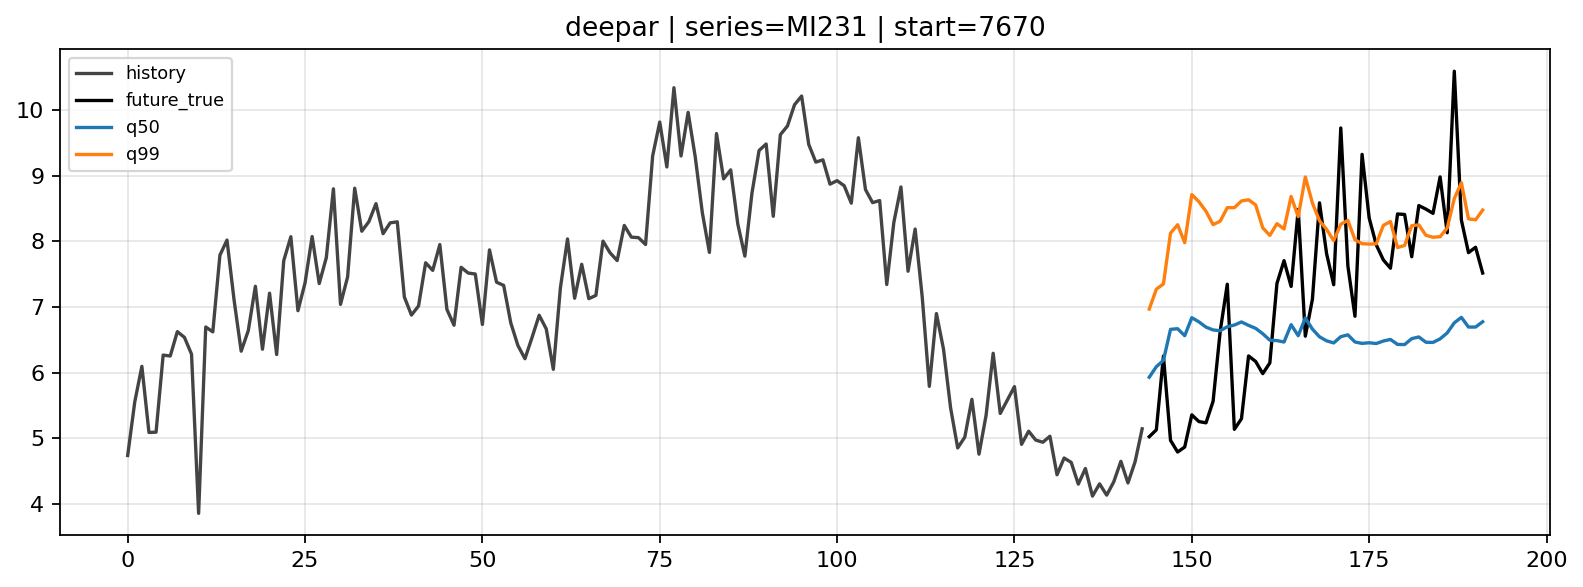

### tft

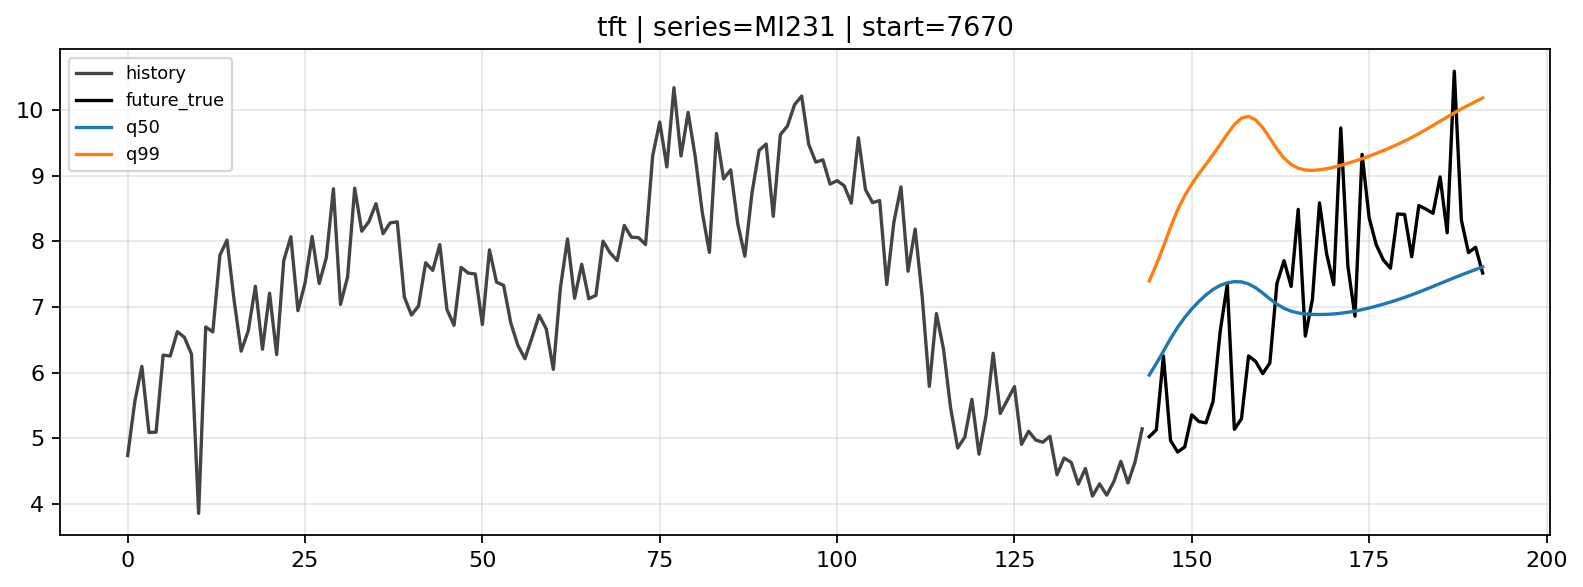

### chronos2

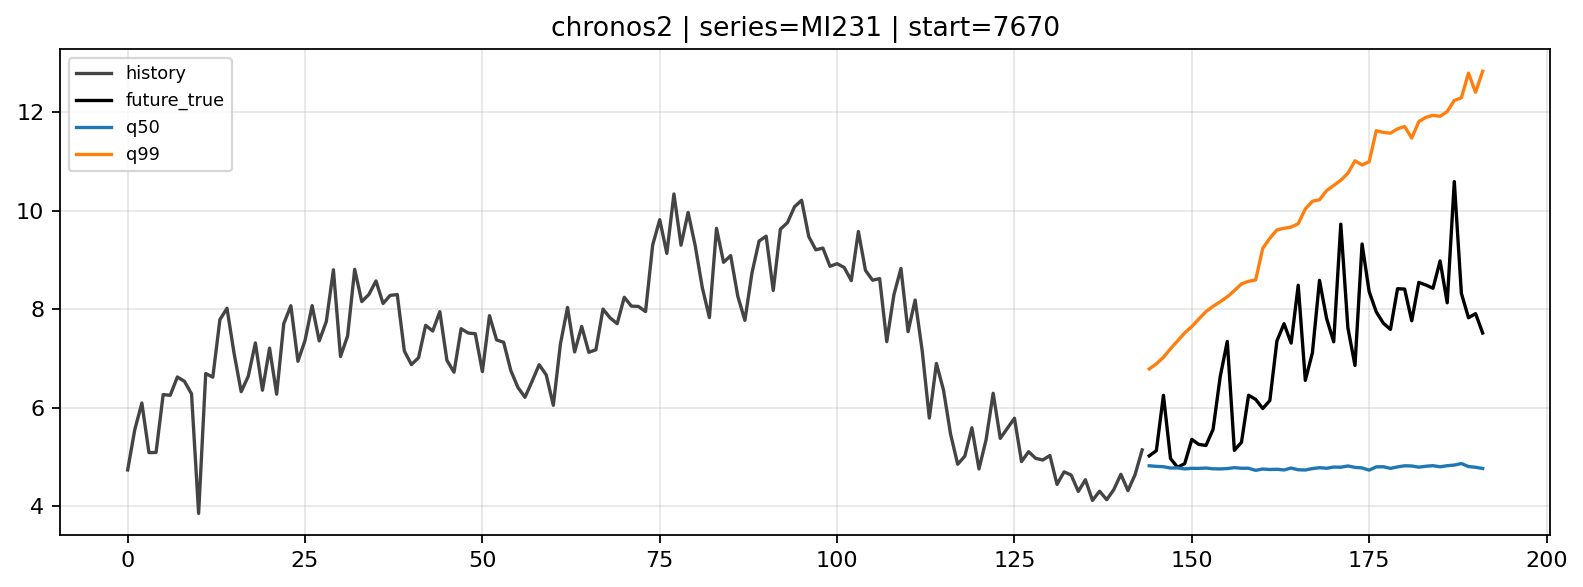

### seasonal_naive

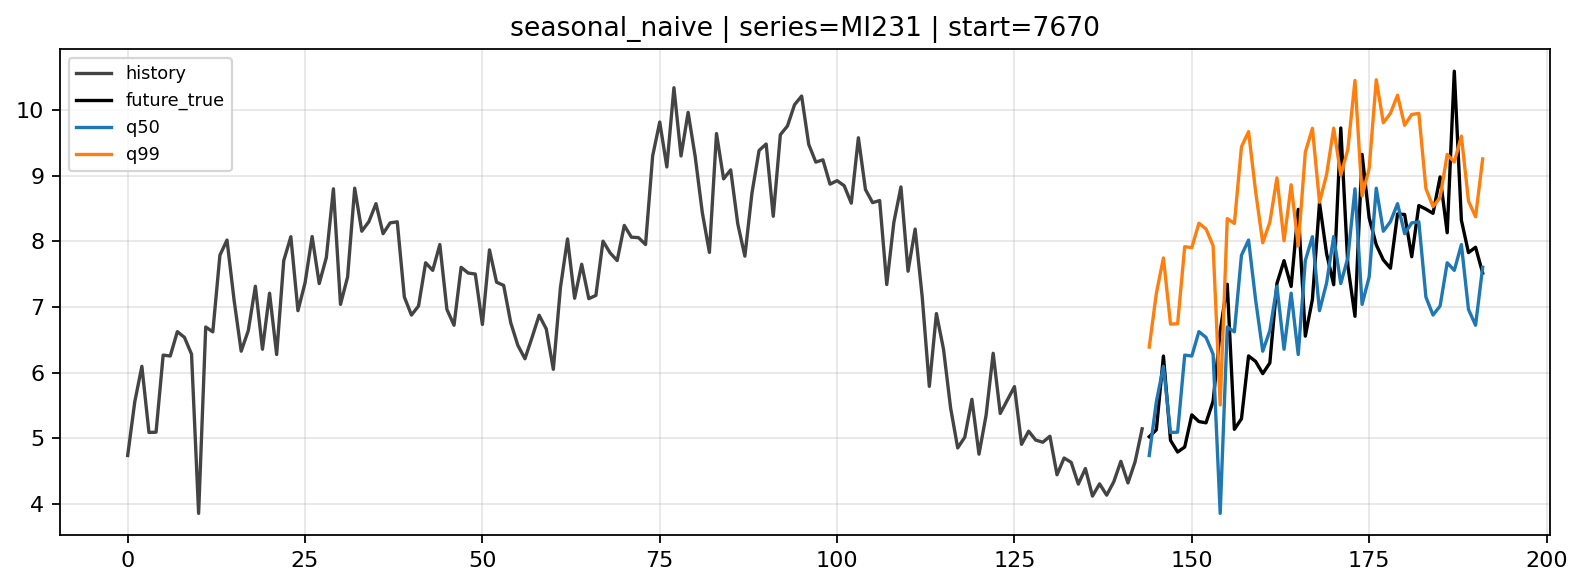

In [5]:
fm = discover_metrics(EXPERIMENT_DIR / "forecast_eval/forecast_eval_summary.json", "*_forecast_metrics.json")
if not fm.empty:
    cols = ["split", "model", "num_windows_total", "rmse_q50", "pinball_q50", "pinball_q95", "coverage_q95", "interval_width_mean"]
    display(fm[[c for c in cols if c in fm.columns]].sort_values(["split", "model"]).reset_index(drop=True))

show_png(REPORTS_DIR / "forecast_eval_test.png", "Forecast Metrics — Test")
show_png(REPORTS_DIR / "forecast_eval_val.png",  "Forecast Metrics — Val")

md("### Forecast Example Windows (Test)")
MODELS = ["lstm", "deepar", "tft", "chronos2", "seasonal_naive"]
for model_name in MODELS:
    show_png(REPORTS_DIR / f"example_windows_{model_name}_test.png", model_name)


## 5. System Evaluation

,split,model,num_windows_total,MAE_CP,tolerance,tolerance_hit_rate,coverage_rate,sharpness
0,test,chronos2,7400,7.415405,3,0.420135,0.981261,6.347760
1,test,deepar,7400,7.189189,3,0.405135,0.949063,2.015789
2,test,lstm,7400,7.216486,3,0.290946,0.998754,9.595717
3,test,seasonal_naive,7400,7.332973,3,0.426757,0.989363,6.883327
4,test,tft,7400,7.153243,3,0.408919,0.995857,5.882435


### System Metrics — Test

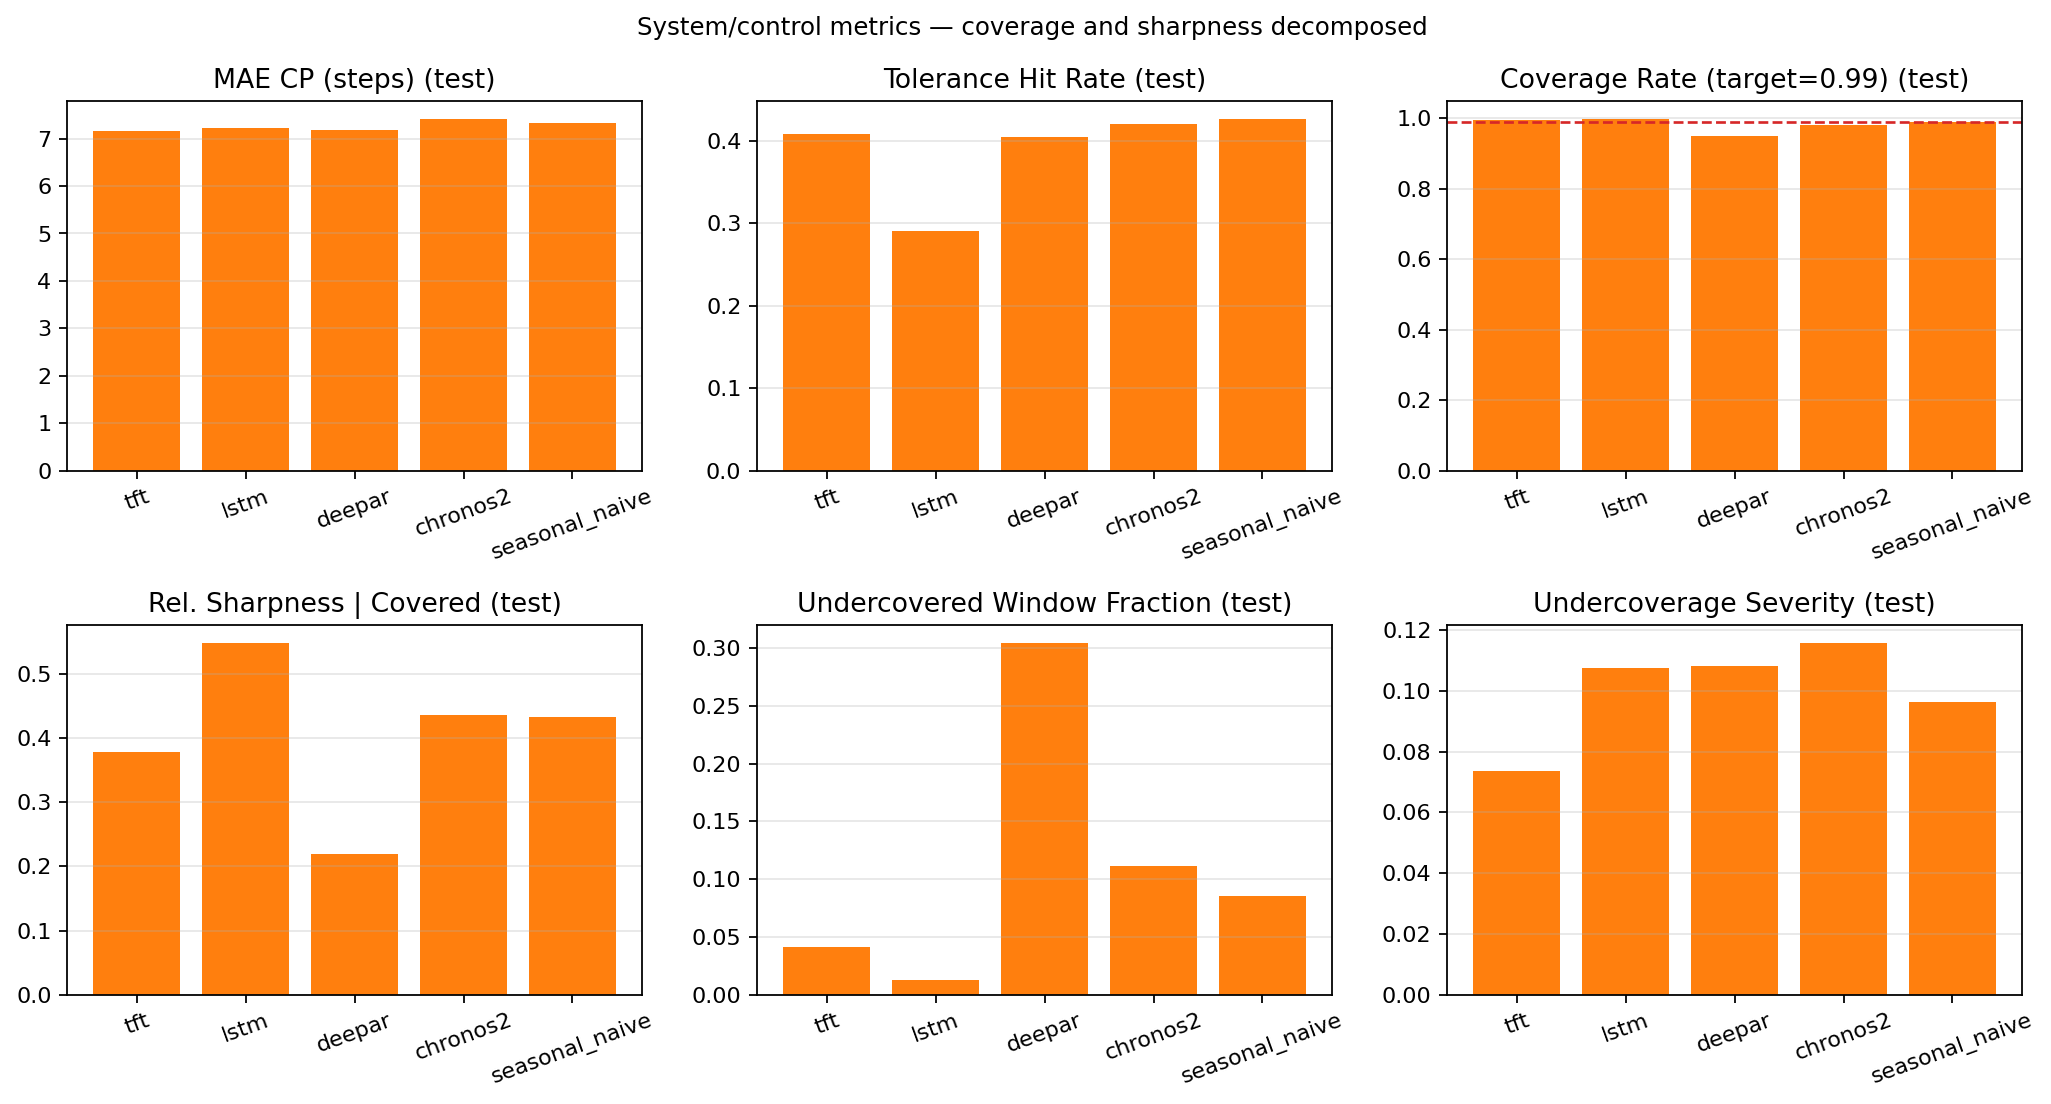

### Pipeline Example Windows — All Models (Test)

### lstm

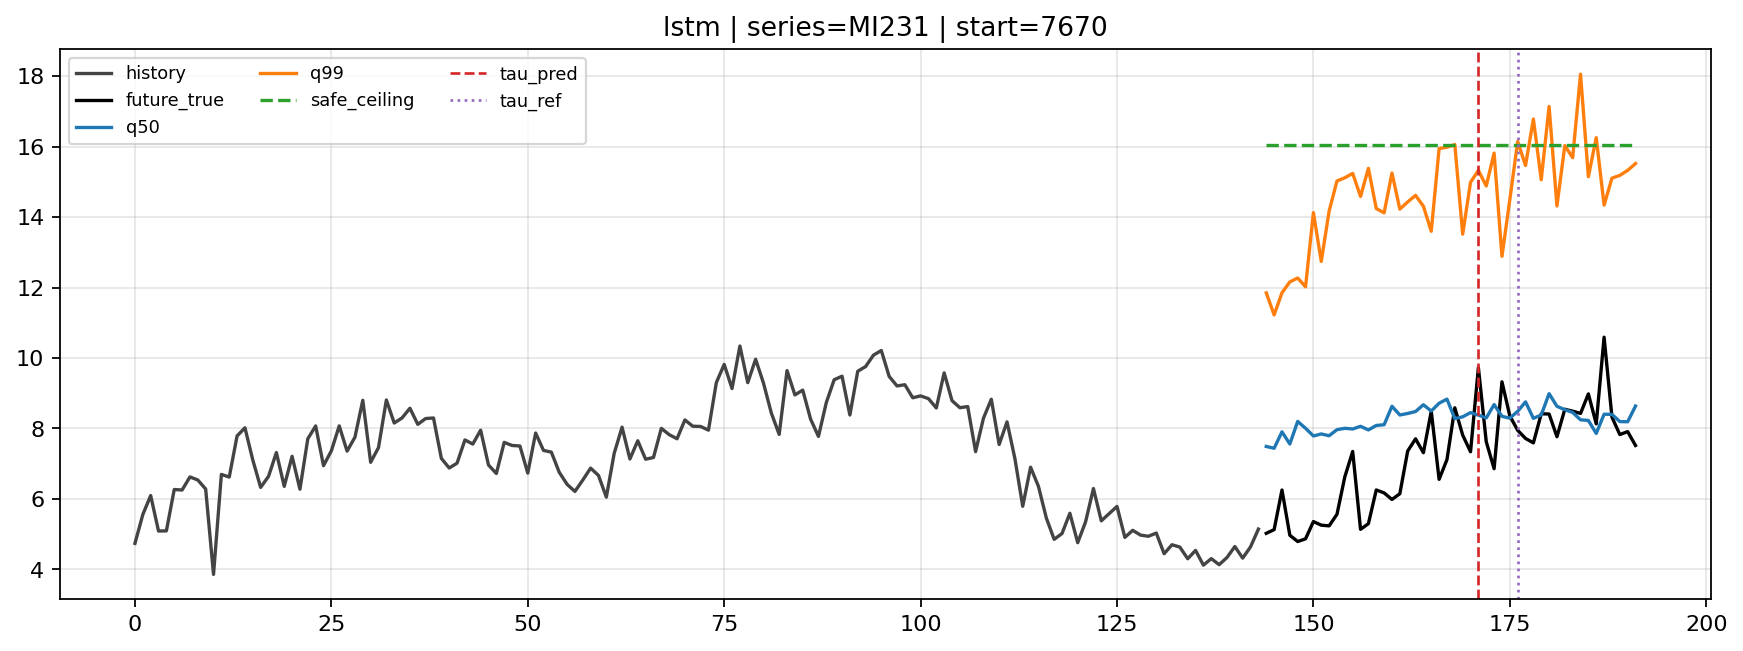

### deepar

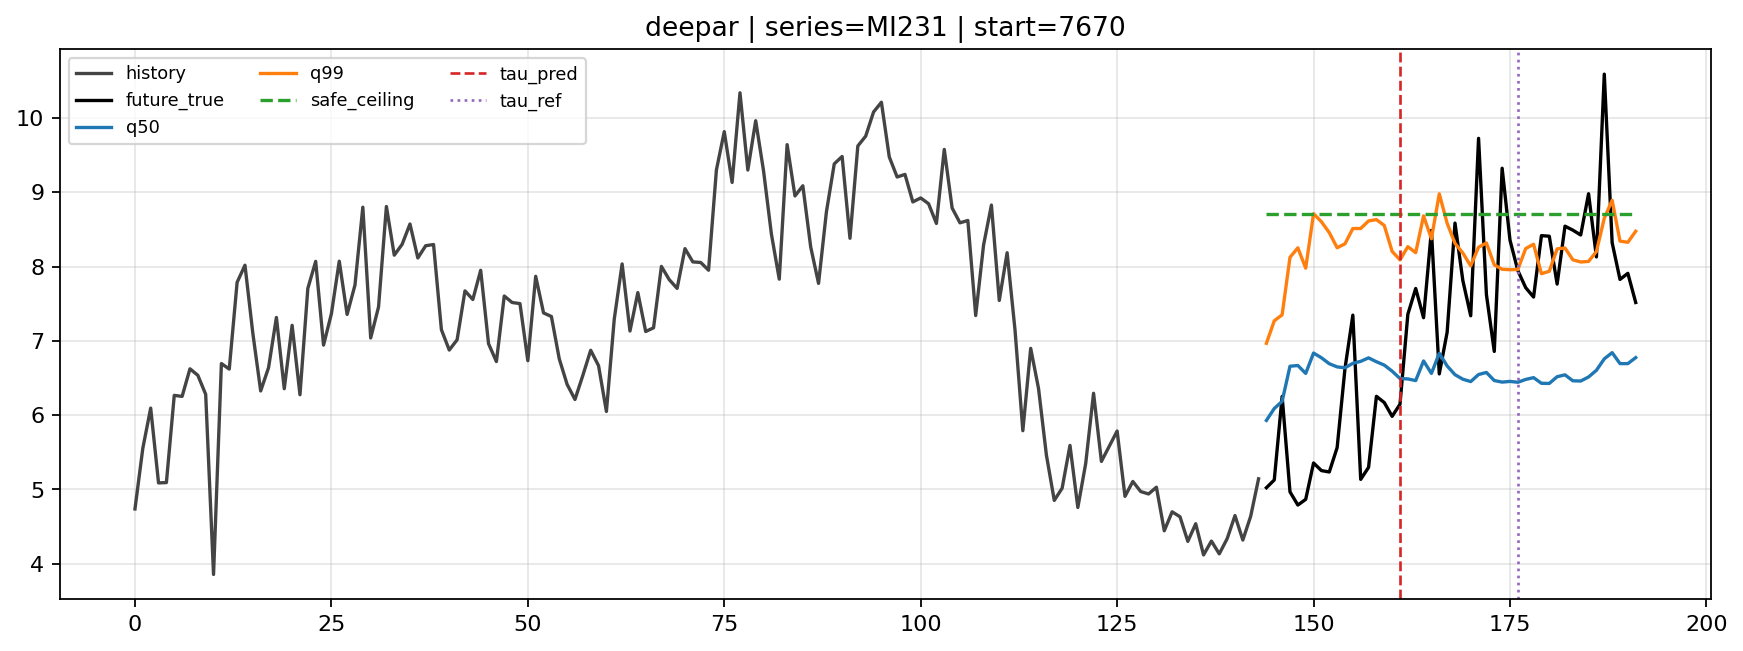

### tft

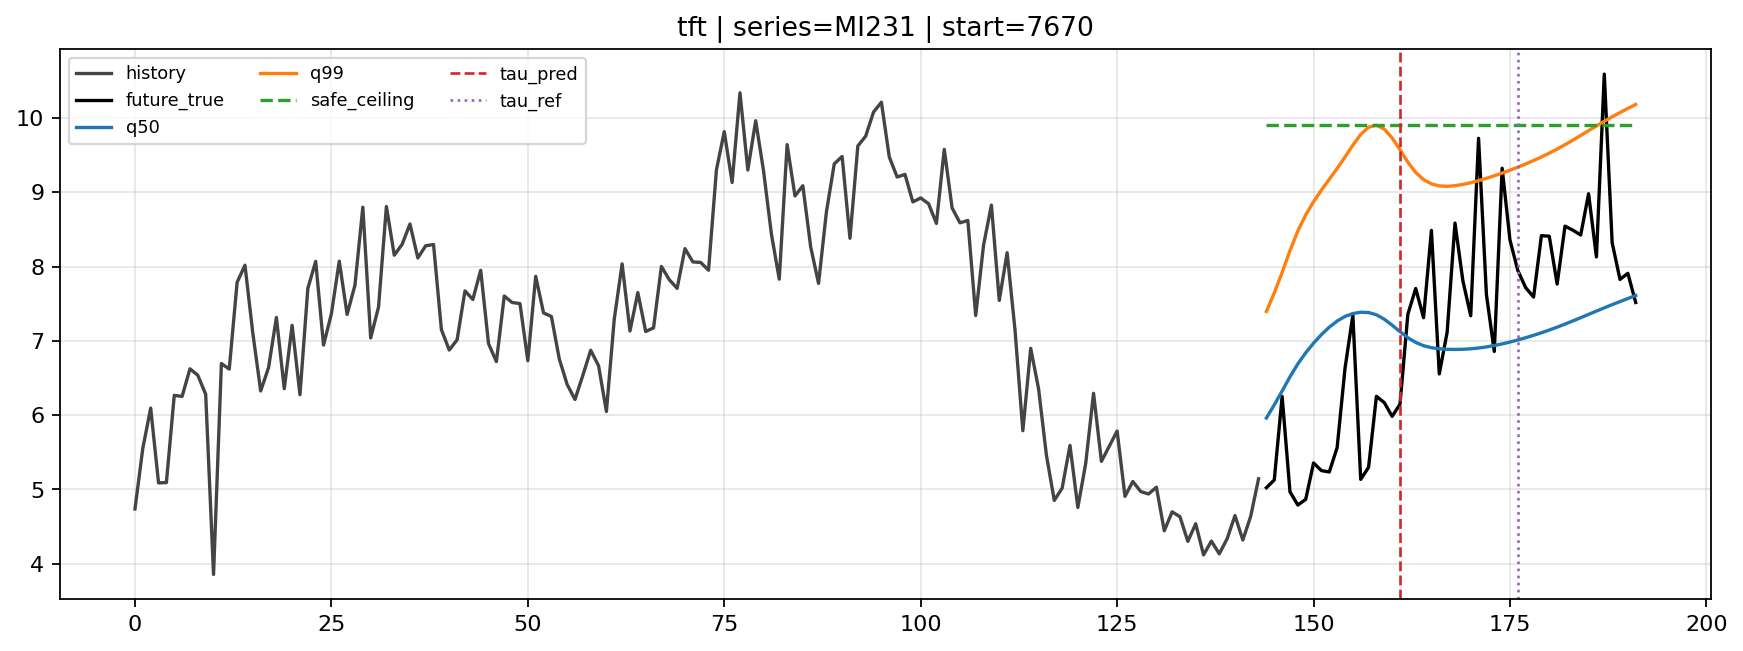

### chronos2

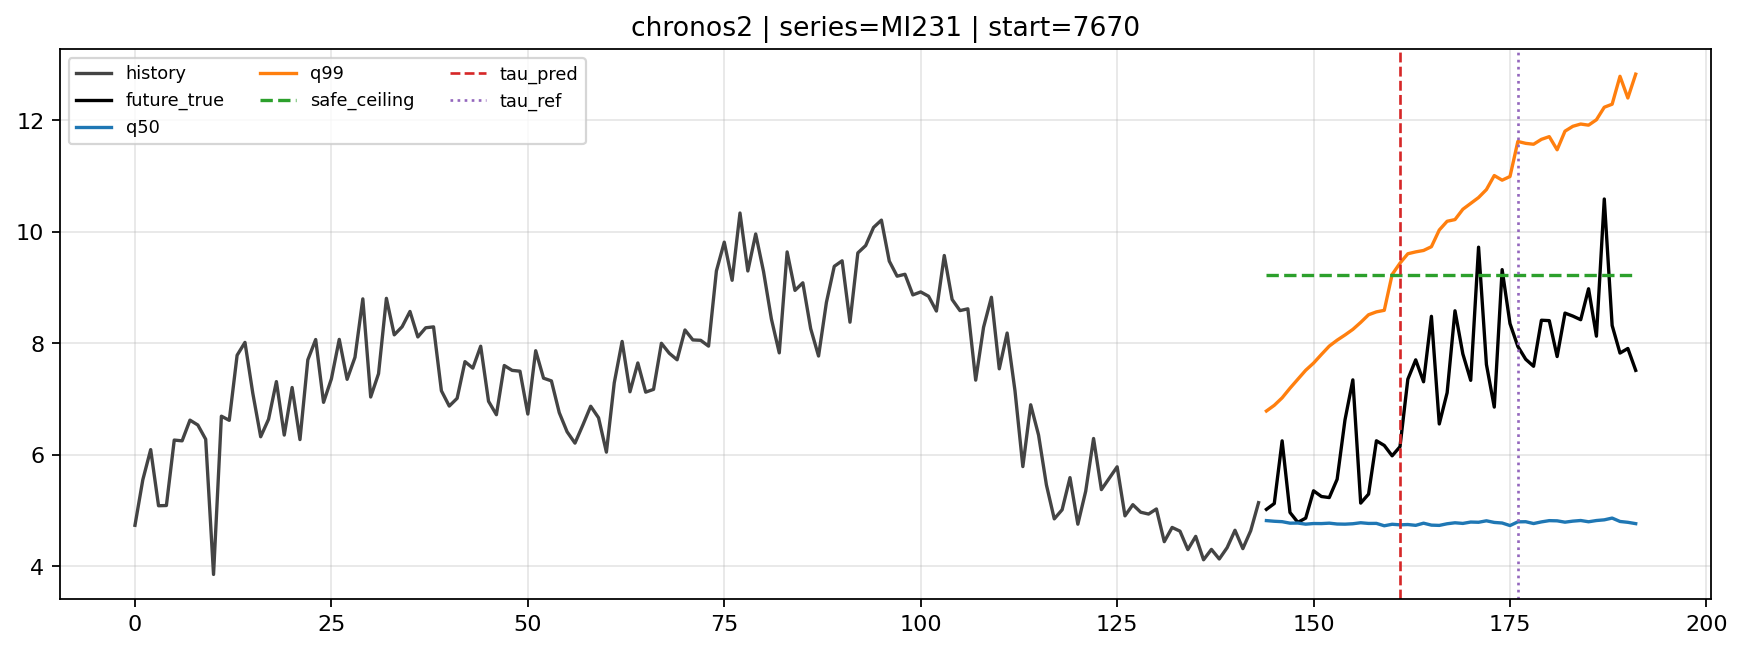

### seasonal_naive

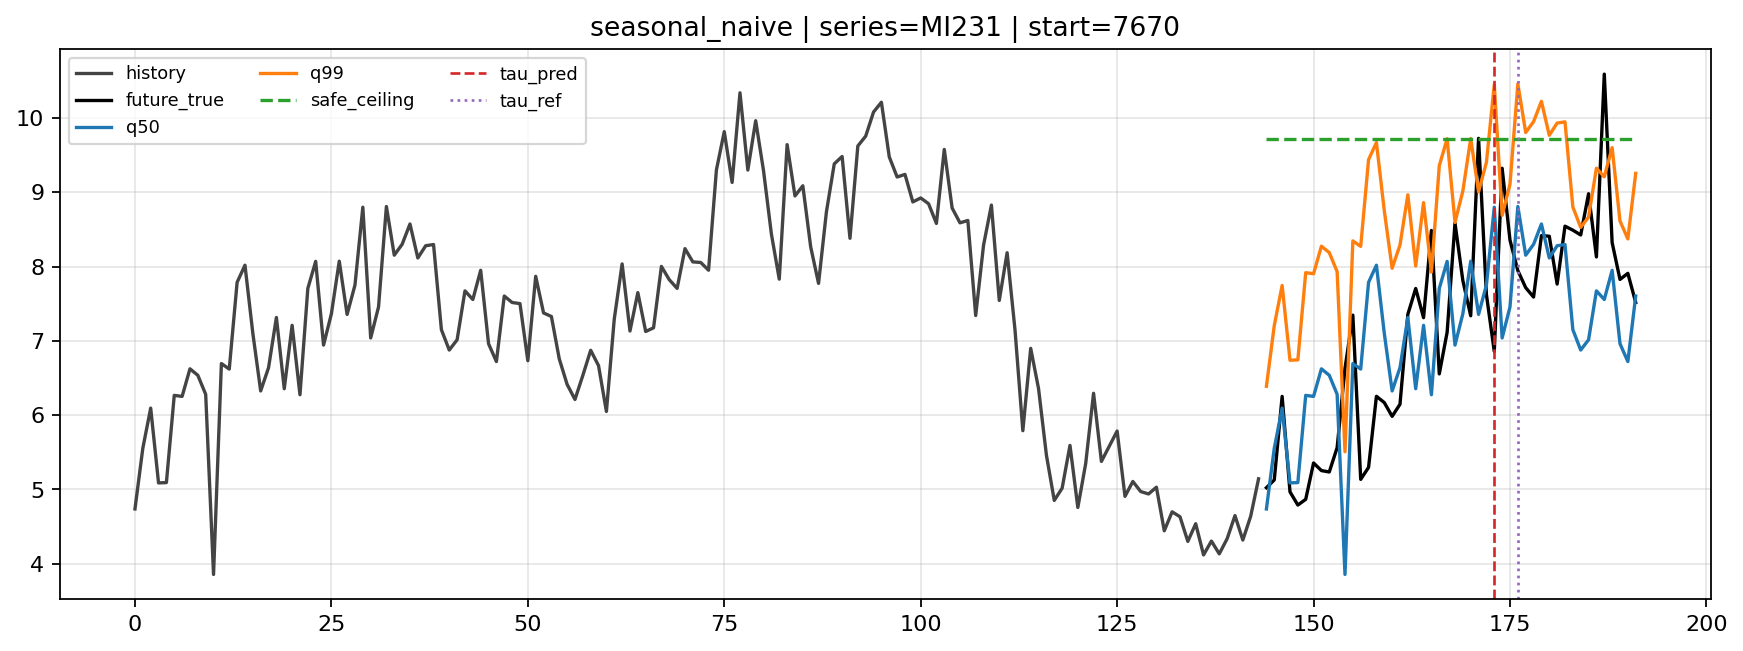

In [6]:
sm = discover_metrics(EXPERIMENT_DIR / "system_eval/system_eval_summary.json", "*_system_metrics.json")
if not sm.empty:
    cols = ["split", "model", "num_windows_total", "MAE_CP", "tolerance", "tolerance_hit_rate", "coverage_rate", "sharpness"]
    display(sm[[c for c in cols if c in sm.columns]].sort_values(["split", "model"]).reset_index(drop=True))

show_png(REPORTS_DIR / "system_eval_test.png", "System Metrics — Test")

md("### Pipeline Example Windows — All Models (Test)")
MODELS = ["lstm", "deepar", "tft", "chronos2", "seasonal_naive"]
for model_name in MODELS:
    show_png(REPORTS_DIR / f"example_windows_system_eval_{model_name}_test.png", model_name)


## 6. Change-Point Sweep

In [7]:
show_png(REPORTS_DIR / "cp_sweep_train.png", "CP Sweep Heatmap — Train")

md("### Best Configs")
show_table(EXPERIMENT_DIR / "cp_sweep/train/cp_sweep_best_configs.csv")


### CP Sweep Heatmap — Train

> PNG not found: `results/experiments/data_tim_milan_10min_trainable_200_ctx144_h48/q50_q99_seed42/reports/cp_sweep_train.png`

### Best Configs

> Missing: `results/experiments/data_tim_milan_10min_trainable_200_ctx144_h48/q50_q99_seed42/cp_sweep/train/cp_sweep_best_configs.csv`

## 7. Tau Calibration

In [8]:
tau_dir = EXPERIMENT_DIR / "tau_calibration"
if (tau_dir / "tau_calibration_summary.csv").exists():
    show_table(tau_dir / "tau_calibration_best_test_rows.csv", "Best Calibrators (Test)")
    show_png(REPORTS_DIR / "tau_calibration_test.png", "Tau Calibration — Test")
    show_png(REPORTS_DIR / "tau_calibration_feature_importance.png", "Feature Importance")
else:
    note("Tau calibration not run. Use `--with-tau-calibration` to generate.")


> Tau calibration not run. Use `--with-tau-calibration` to generate.

## 8. Calibrated System Evaluation

In [9]:
if CALIBRATED_PATH.exists():
    show_table(CALIBRATED_PATH, "Raw vs Calibrated Metrics")
    show_png(REPORTS_DIR / "calibrated_system_eval_test.png", "Calibrated System Eval — Test")
else:
    note("Calibrated system-eval not run. Re-run pipeline with `--with-tau-calibration`.")


> Calibrated system-eval not run. Re-run pipeline with `--with-tau-calibration`.